In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks
import csv
from garmin_fit_sdk import Decoder, Stream

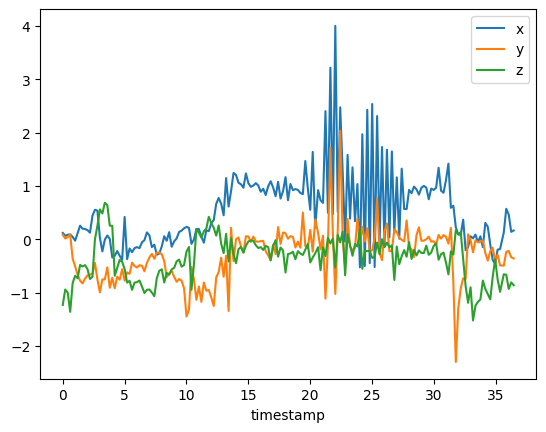

In [3]:
df = pd.read_csv('Data.csv')
df.plot(x = 'timestamp')
plt.show()

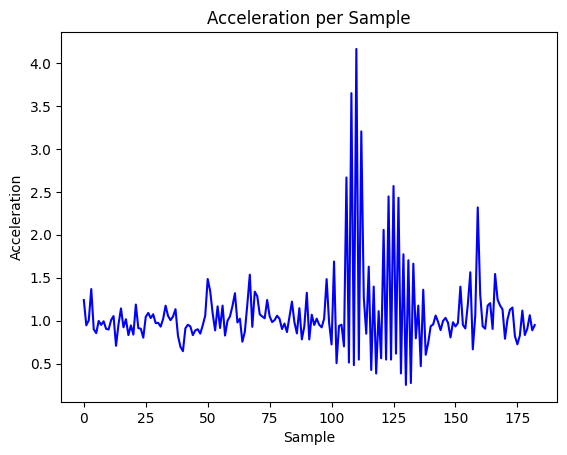

In [ ]:
time = df["timestamp"].values
ax = df["x"].values
ay = df["y"].values
az = df["z"].values


# Acceleration Magnitude Computation


acc_mag = np.sqrt(ax**2 + ay**2 + az**2)
plt.plot(acc_mag, label='Acceleration Magnitude', color='blue', linewidth=1.5)
plt.ylabel("Acceleration")
plt.xlabel("Sample")
plt.title("Acceleration per Sample")
plt.savefig("no_filtering", dpi=300, bbox_inches="tight")
plt.show()



<function matplotlib.pyplot.show(close=None, block=None)>

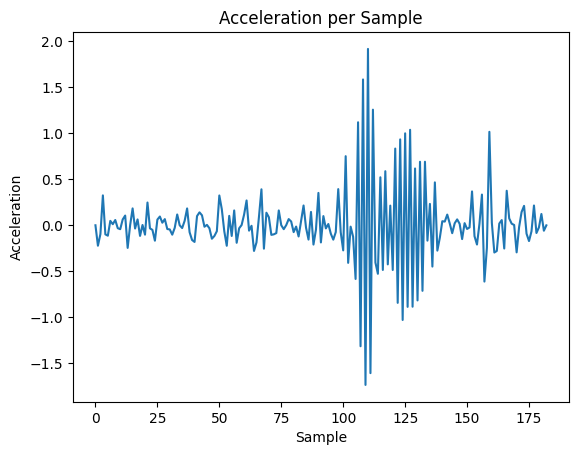

In [15]:
fs = 5  # sampling frequency (Hz)

def highpass_filter(signal, cutoff=0.5, fs=100, order=4):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='high')
    return filtfilt(b, a, signal)

filtered_acc = highpass_filter(acc_mag, cutoff=0.5, fs=fs)
plt.plot(filtered_acc)
plt.ylabel("Acceleration")
plt.xlabel("Sample")
plt.title("Acceleration per Sample")
plt.savefig("with_filtering", dpi=300, bbox_inches="tight")
plt.show

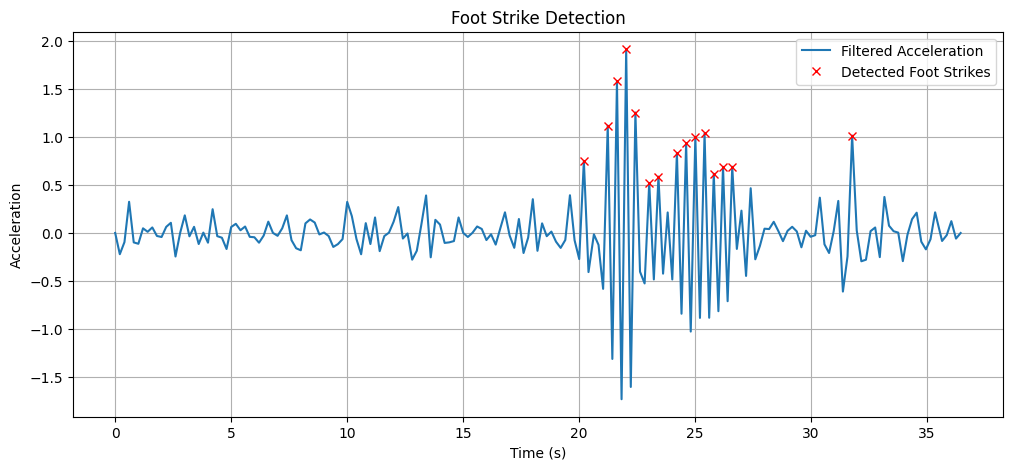

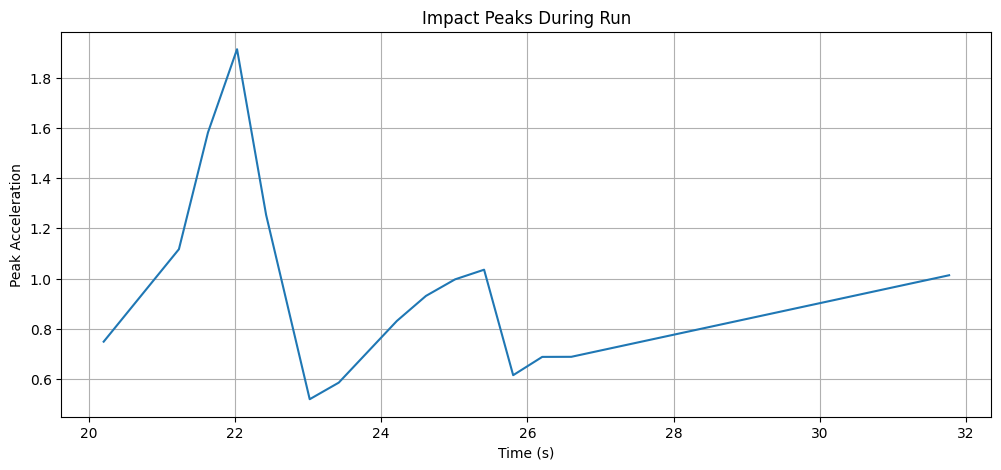

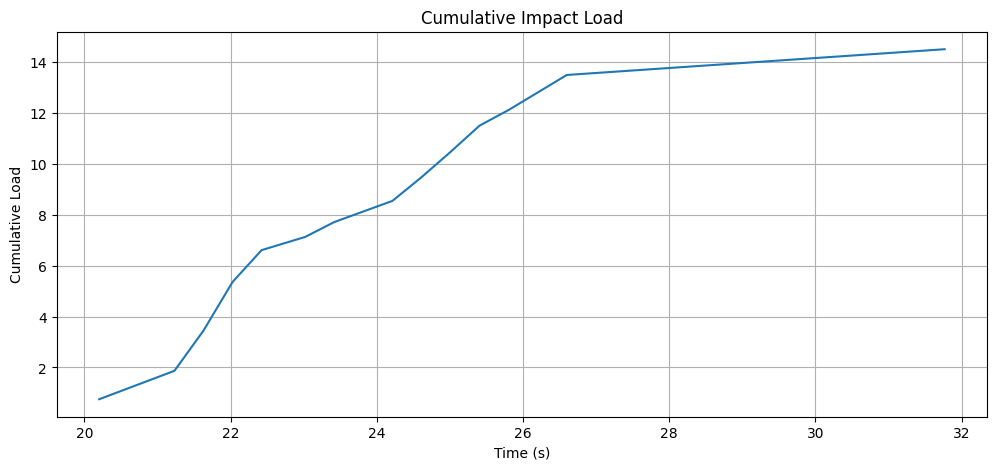

Detected steps: 15
Estimated cadence: 24.7 steps/min
Mean peak acceleration: 0.97
Max peak acceleration: 1.91


In [ ]:
time = df["timestamp"].values
ax = df["x"].values
ay = df["y"].values
az = df["z"].values

# Acceleration Magnitude Computation

acc_mag = np.sqrt(ax**2 + ay**2 + az**2)

# Filtering

fs = 5  # sampling frequency (Hz)

def highpass_filter(signal, cutoff=0.5, fs=100, order=4):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='high')
    return filtfilt(b, a, signal)

filtered_acc = highpass_filter(acc_mag, cutoff=0.5, fs=fs)

# Foot-strike Detection

min_distance = int(0.2 * fs)

peaks, properties = find_peaks(
    filtered_acc,
    height=0.5,      
    distance=min_distance
)

peak_times = time[peaks]
peak_values = filtered_acc[peaks]

# Cumulative Load Calculation
cumulative_load = np.cumsum(peak_values)

# Foot strike plot

plt.figure(figsize=(12,5))
plt.plot(time, filtered_acc, label="Filtered Acceleration")
plt.plot(peak_times, peak_values, "rx", label="Detected Foot Strikes")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration")
plt.title("Foot Strike Detection")
plt.savefig("foot_strike", dpi=300, bbox_inches="tight")
plt.legend()
plt.grid(True)

# Cumulative Load Plot

plt.figure(figsize=(12,5))
plt.plot(peak_times, cumulative_load)
plt.xlabel("Time (s)")
plt.ylabel("Cumulative Load")
plt.title("Cumulative Impact Load")
plt.savefig("cum_load", dpi=300, bbox_inches="tight")
plt.grid(True)

plt.show()

# Basic Data

cadence = len(peaks) / (time[-1] / 60)

# Chatgpt helped with printing these
print(f"Detected steps: {len(peaks)}")
print(f"Estimated cadence: {cadence:.1f} steps/min")
print(f"Mean peak acceleration: {np.mean(peak_values):.2f}")
print(f"Max peak acceleration: {np.max(peak_values):.2f}")

below this is code to get a csv of accelerometer data from a .fit file. I was experimenting using CHATGPT for this part

In [ ]:
#=========================================================
# PUT YOUR .FIT FILE PATH HERE
# Example:
# fit_path = r"C:\Users\yourname\Downloads\activity.fit"
# =========================================================
fit_path = r"C:\School\UCSD\Senior Year\ECE 284\22942860594_ACTIVITY.fit"

# Read FIT file
stream = Stream.from_file(fit_path)
decoder = Decoder(stream)

messages, errors = decoder.read()

# Print any decoding errors
print("Errors:", errors)

# Show available message types
print("\nAvailable message types:")
for key in messages.keys():
    print("-", key)

# Extract record messages
records = messages["record_mesgs"]

# Output CSV filename
csv_output = "output.csv"

# Write CSV
with open(csv_output, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=records[0].keys())
    writer.writeheader()
    writer.writerows(records)

print(f"\nCSV saved as: {csv_output}")

Errors: []

Available message types:
- file_id_mesgs
- file_creator_mesgs
- 288
- 327
- 326
- event_mesgs
- device_info_mesgs
- 22
- 141
- device_settings_mesgs
- user_profile_mesgs
- 147
- 79
- sport_mesgs
- training_settings_mesgs
- zones_target_mesgs
- developer_data_id_mesgs
- field_description_mesgs
- record_mesgs
- 233
- gps_metadata_mesgs
- 325
- 104
- lap_mesgs
- time_in_zone_mesgs
- 140
- session_mesgs
- activity_mesgs

CSV saved as: output.csv
